In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


In [3]:
dataset = pd.read_csv('spam.csv', encoding='latin-1')


In [5]:
# Build pipeline
model = Pipeline([
    ('tfidf', TfidfVectorizer()),
    ('clf', MultinomialNB())
])

# Train
model.fit(dataset['v2'], dataset['v1'])


Pipeline(steps=[('tfidf', TfidfVectorizer()), ('clf', MultinomialNB())])

In [6]:
def predict_message(message):
    pred_prob = model.predict_proba([message])[0]
    pred = model.predict([message])[0]
    return [float(pred_prob[1]), pred]


In [7]:
acc = model.score(dataset['v2'], dataset['v1'])
print(f"Accuracy: {acc}")

Accuracy: 0.9763101220387652


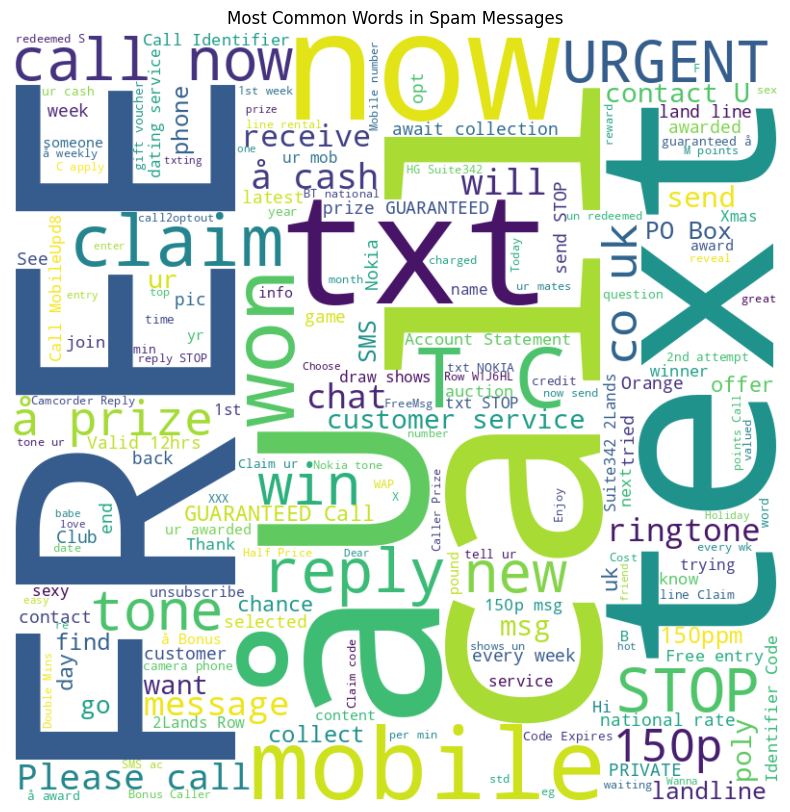

In [13]:
from wordcloud import WordCloud

# Filter for spam messages
spam_messages = dataset[dataset['v1'] == 'spam']['v2']

# Join all spam messages into a single string
spam_text = " ".join(spam_messages)

# Generate the word cloud
wordcloud = WordCloud(width=800, height=800, background_color='white', stopwords=None, min_font_size=10).generate(spam_text)

# Display the word cloud using imshow
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Spam Messages')
plt.grid(True)
plt.show()